# 02 - 需求與出貨分析

## 目的

本筆記本旨在研究**新訂單**和**出貨量**隨時間的變化情況，為建立任何預測模型奠定基礎。

目標是回答規劃人員的三個問題：

1. 需求是在增強還是減弱？

2. 出貨量是否能跟上訂單成長？

3. 訂單流的履行難度是否增加？

## 主要規劃指標

- **新訂單**：新增的生產需求。

- **出貨量**：已完成並已出貨的生產價值。

- **訂單缺口** = 新訂單 - 出貨量。

- **訂單出貨比** = 新訂單 / 出貨量。

- **3個月訂單出貨比**：更平滑地反映近期訂單壓力。

- **12個月訂單與出貨量比較**：較長期的需求與產出比較。

> 這份筆記僅供描述。它尚未預測未來的訂單，也沒有聲稱新訂單直接等於 ASE 的客戶需求。

## Step 1｜載入分析套件

### 這一格要做什麼？

載入這本 Notebook 需要的工具：

- `Path`：處理專案資料夾路徑。
- `numpy`：處理數值。
- `pandas`：整理 Planner 月度資料。
- `matplotlib`：畫趨勢圖。
- `display`：讓表格在 Notebook 中完整顯示。

### 為什麼這一步存在？

`01_data_validation.ipynb` 已經負責確認資料品質；02 不重新下載官方資料，而是直接讀取通過驗證後的 Processed Dataset，避免分析流程重複。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")


Libraries loaded successfully.


### 輸出解讀

實際輸出：

```text
Libraries loaded successfully.
```

代表 `Path`、`numpy`、`pandas`、`matplotlib` 與 `display` 都成功載入，這一格沒有 Import Error。

**白話來說：**目前 Python 分析環境正常，可以直接使用 01 已經整理好的 Processed Dataset，不需要重新下載資料。

**下一步：**讀取 `monthly_planning_data.csv`，確認 02 是否正確接上 01 的成果。


## Step 2｜讀取 01 驗證完成的 Planner Dataset

### 這一格要做什麼？

讀取：

`data/processed/monthly_planning_data.csv`

並把 `date` 轉成真正的日期格式，再依月份排序。

### 為什麼只使用 Processed Data？

因為 01 已經完成：

- 缺值檢查
- 重複月份檢查
- 缺月檢查
- 五個 Series 合併
- PASS / FAIL 資料品質檢查

02 的任務是分析商業現象，不應重新混入未驗證的 Raw Data。


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "monthly_planning_data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {DATA_PATH}\n"
        "Please run 01_data_validation.ipynb first."
    )

planning_data = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"],
)

planning_data = (
    planning_data
    .sort_values("date")
    .reset_index(drop=True)
)

print("Loaded:", DATA_PATH)
print("Shape:", planning_data.shape)

display(planning_data.head())
display(planning_data.tail())


Loaded: C:\Users\momo8\Desktop\electronic-components-planning\data\processed\monthly_planning_data.csv
Shape: (415, 6)


,date,new_orders,shipments,unfilled_orders,inventories,industrial_production
0,1992-02-01,3411,3484,8656,7714,0.3629
1,1992-03-01,3711,3754,8613,7661,0.3675
2,1992-04-01,3745,3652,8706,7520,0.3725
3,1992-05-01,3735,3673,8768,7427,0.3777
4,1992-06-01,3814,3701,8881,7585,0.3903


,date,new_orders,shipments,unfilled_orders,inventories,industrial_production
410,2026-04-01,5405,5319,18494,13382,176.6948
411,2026-05-01,5579,5438,18635,13473,184.1891
412,2026-06-01,5668,5567,18736,13989,187.5187
413,2026-07-01,5711,5570,18877,14001,190.2607
414,2026-08-01,5769,5625,19021,14129,190.0987


### 輸出解讀

這次實際讀到：

```text
Shape: (415, 6)
```

日期從 **1992-02** 到 **2026-08**，欄位共有 6 個：

- `date`
- `new_orders`
- `shipments`
- `unfilled_orders`
- `inventories`
- `industrial_production`

最新幾個月也都有正常資料，例如 2026-08：

- New Orders = **5,769 百萬美元**
- Shipments = **5,625 百萬美元**
- Unfilled Orders = **19,021 百萬美元**
- Inventories = **14,129 百萬美元**
- Industrial Production = **190.0987**

**白話來說：**02 已經正確讀到 01 通過驗證的 Planner 主資料，而且資料一路更新到 2026-08。

這裡先不要把 19,021 的 Backlog 拿來下結論，因為本 Notebook 的主題是 **Orders vs Shipments**；Backlog 會留到 03 正式分析。

**下一步：**再做一次輕量安全檢查，確認 02 拿到的檔案沒有被修改壞掉。


## Step 3｜分析前安全檢查

### 這一格要做什麼？

雖然 01 已經驗證過資料，但 02 仍要確認目前讀到的檔案至少符合這本分析需要：

- 必要欄位存在。
- 日期沒有重複。
- New Orders 與 Shipments 沒有空值。
- New Orders 與 Shipments 都大於等於 0。
- Shipments 不能為 0，否則 Book-to-Bill 會無法計算。

### 為什麼還要再檢查？

因為 `monthly_planning_data.csv` 有可能在 01 執行後被手動改過。這是一個輕量的 defensive check，避免錯誤一路傳到 KPI。


In [3]:
required_columns = {
    "date",
    "new_orders",
    "shipments",
    "unfilled_orders",
    "inventories",
    "industrial_production",
}

missing_columns = required_columns - set(planning_data.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if planning_data["date"].duplicated().any():
    raise ValueError("Duplicate monthly dates were found.")

if planning_data[["new_orders", "shipments"]].isna().any().any():
    raise ValueError("New Orders or Shipments contains missing values.")

if (planning_data["new_orders"] < 0).any():
    raise ValueError("New Orders contains negative values.")

if (planning_data["shipments"] < 0).any():
    raise ValueError("Shipments contains negative values.")

if (planning_data["shipments"] == 0).any():
    raise ValueError(
        "Shipments contains zero values, so Book-to-Bill cannot be calculated safely."
    )

print("ANALYSIS INPUT CHECK: PASS")
print(
    "Date range:",
    planning_data["date"].min().date(),
    "to",
    planning_data["date"].max().date(),
)
print("Rows:", len(planning_data))


ANALYSIS INPUT CHECK: PASS
Date range: 1992-02-01 to 2026-08-01
Rows: 415


### 輸出解讀

實際輸出：

```text
ANALYSIS INPUT CHECK: PASS
Date range: 1992-02-01 to 2026-08-01
Rows: 415
```

代表這本 Notebook 需要的核心欄位都存在，而且：

- 日期沒有重複。
- New Orders / Shipments 沒有空值。
- New Orders / Shipments 沒有負數。
- Shipments 沒有 0，因此可以安全計算 Book-to-Bill。

**白話來說：**目前拿到的是一份可以安全做「需求流入 vs 出貨」分析的月資料，不會因為缺值或除以 0 讓 KPI 失真。

**下一步：**開始把原始金額轉成 Planner 可以直接判讀的 KPI。


## Step 4｜建立 Demand vs Shipment KPI

### 這一格要做什麼？

在原始欄位之外，建立幾個 Planner 容易理解的衍生指標。

### 1. Order Gap

`New Orders - Shipments`

- 正值：這個月新進訂單金額高於出貨金額。
- 負值：這個月出貨金額高於新進訂單金額。

### 2. Book-to-Bill

`New Orders / Shipments`

- `> 1`：New Orders 大於 Shipments。
- `= 1`：兩者大致相同。
- `< 1`：Shipments 大於 New Orders。

### 3. MoM

Month-over-Month，和上個月相比。

### 4. YoY

Year-over-Year，和去年同月相比。

### 5. 3-Month Moving Average

用最近 3 個月平均降低單月波動，讓 Planner 更容易看出短期方向。

> 重要：Book-to-Bill 是產業層級的金額比率，不等於 ASE 單一客戶或單一產品的接單／出貨比。


In [4]:
analysis_data = planning_data.copy()

analysis_data["order_gap"] = (
    analysis_data["new_orders"]
    - analysis_data["shipments"]
)

analysis_data["book_to_bill"] = (
    analysis_data["new_orders"]
    / analysis_data["shipments"]
)

analysis_data["new_orders_mom_pct"] = (
    analysis_data["new_orders"]
    .pct_change(fill_method=None)
    * 100
)

analysis_data["shipments_mom_pct"] = (
    analysis_data["shipments"]
    .pct_change(fill_method=None)
    * 100
)

analysis_data["new_orders_yoy_pct"] = (
    analysis_data["new_orders"]
    .pct_change(periods=12, fill_method=None)
    * 100
)

analysis_data["shipments_yoy_pct"] = (
    analysis_data["shipments"]
    .pct_change(periods=12, fill_method=None)
    * 100
)

analysis_data["new_orders_3m_avg"] = (
    analysis_data["new_orders"]
    .rolling(window=3)
    .mean()
)

analysis_data["shipments_3m_avg"] = (
    analysis_data["shipments"]
    .rolling(window=3)
    .mean()
)

analysis_data["order_gap_3m_avg"] = (
    analysis_data["order_gap"]
    .rolling(window=3)
    .mean()
)

analysis_data["book_to_bill_3m"] = (
    analysis_data["new_orders_3m_avg"]
    / analysis_data["shipments_3m_avg"]
)

print("Planner KPIs created successfully.")

display(
    analysis_data[
        [
            "date",
            "new_orders",
            "shipments",
            "order_gap",
            "book_to_bill",
            "new_orders_yoy_pct",
            "shipments_yoy_pct",
            "book_to_bill_3m",
        ]
    ].tail(12)
)


Planner KPIs created successfully.


,date,new_orders,shipments,order_gap,book_to_bill,new_orders_yoy_pct,shipments_yoy_pct,book_to_bill_3m
403,2025-09-01,5132,5174,-42,0.991882,6.938946,5.098517,0.996398
404,2025-10-01,5264,5207,57,1.010947,8.805291,6.221950,0.999293
405,2025-11-01,5288,5253,35,1.006663,7.414178,6.228514,1.003198
406,2025-12-01,5293,5315,-22,0.995861,8.020408,6.920137,1.004437
407,2026-01-01,5382,5310,72,1.013559,10.831960,7.207753,1.005353
408,2026-02-01,5348,5302,46,1.008676,8.544753,4.969313,1.006028
409,2026-03-01,5406,5282,124,1.023476,5.032058,3.184216,1.015226
410,2026-04-01,5405,5319,86,1.016168,8.577742,5.118577,1.016098
411,2026-05-01,5579,5438,141,1.025929,8.372183,7.619236,1.021884
412,2026-06-01,5668,5567,101,1.018143,9.167951,7.098884,1.020093


### 輸出解讀

這格成功建立：

- `order_gap`
- `book_to_bill`
- Orders / Shipments 的 MoM
- Orders / Shipments 的 YoY
- 3 個月平均
- 3-Month Book-to-Bill

最新 12 個月的實際結果已經出現很明顯的變化。

例如 2026-08：

- New Orders = **5,769**
- Shipments = **5,625**
- Order Gap = **+144**
- Book-to-Bill = **1.0256**
- New Orders YoY = **+11.85%**
- Shipments YoY = **+8.51%**
- 3M Book-to-Bill = **1.0230**

**白話來說：**

2026-08 的新訂單金額比當月出貨多 **144 百萬美元**。而且和去年同月相比，New Orders 成長約 **11.85%**，Shipments 成長約 **8.51%**，也就是目前 New Orders 的年增速度比 Shipments 快約 **3.34 個百分點**。

3M Book-to-Bill = **1.023** 則表示最近三個月平均來看，Orders 仍稍微高於 Shipments，不只是 8 月單月突然出現。

⚠️ **不能直接說「產能不足」或「一定延遲」。**  
這一格只能說目前出現 **Demand Inflow > Shipment Output** 的訊號，真正是否形成履約壓力還要看 Backlog。

**下一步：**把最近 12 個月完整拉出來，確認這個現象是不是持續發生。


## Step 5｜查看最近 12 個月的 Orders 與 Shipments

### 這一格要做什麼？

只顯示最近 12 個月，先回答：

- New Orders 最近是在上升還是下降？
- Shipments 有沒有同步跟上？
- 每個月 Order Gap 是正還是負？
- Book-to-Bill 最近大多在 1 上方還是下方？

### 為什麼先看 12 個月？

完整資料從 1992 年開始，直接看全期間很容易被長期結構變化干擾。Planner 日常判斷通常更重視近期變化。


In [5]:
recent_12m = analysis_data.tail(12).copy()

recent_12m_display = recent_12m[
    [
        "date",
        "new_orders",
        "shipments",
        "order_gap",
        "book_to_bill",
        "new_orders_mom_pct",
        "new_orders_yoy_pct",
        "shipments_yoy_pct",
    ]
].copy()

for column in [
    "book_to_bill",
    "new_orders_mom_pct",
    "new_orders_yoy_pct",
    "shipments_yoy_pct",
]:
    recent_12m_display[column] = recent_12m_display[column].round(2)

display(recent_12m_display)

latest = analysis_data.iloc[-1]

print()
print("LATEST MONTH SUMMARY")
print("-" * 60)
print("Date:", latest["date"].strftime("%Y-%m"))
print(f"New Orders: {latest['new_orders']:,.0f} million USD")
print(f"Shipments: {latest['shipments']:,.0f} million USD")
print(f"Order Gap: {latest['order_gap']:,.0f} million USD")
print(f"Book-to-Bill: {latest['book_to_bill']:.3f}")
print(f"New Orders YoY: {latest['new_orders_yoy_pct']:.2f}%")
print(f"Shipments YoY: {latest['shipments_yoy_pct']:.2f}%")

if latest["book_to_bill"] > 1:
    print(
        "Plain-language read: incoming orders were higher than shipments in the latest month."
    )
elif latest["book_to_bill"] < 1:
    print(
        "Plain-language read: shipments were higher than incoming orders in the latest month."
    )
else:
    print(
        "Plain-language read: incoming orders and shipments were equal in the latest month."
    )


,date,new_orders,shipments,order_gap,book_to_bill,new_orders_mom_pct,new_orders_yoy_pct,shipments_yoy_pct
403,2025-09-01,5132,5174,-42,0.99,-0.50,6.94,5.10
404,2025-10-01,5264,5207,57,1.01,2.57,8.81,6.22
405,2025-11-01,5288,5253,35,1.01,0.46,7.41,6.23
406,2025-12-01,5293,5315,-22,1.00,0.09,8.02,6.92
407,2026-01-01,5382,5310,72,1.01,1.68,10.83,7.21
408,2026-02-01,5348,5302,46,1.01,-0.63,8.54,4.97
409,2026-03-01,5406,5282,124,1.02,1.08,5.03,3.18
410,2026-04-01,5405,5319,86,1.02,-0.02,8.58,5.12
411,2026-05-01,5579,5438,141,1.03,3.22,8.37,7.62
412,2026-06-01,5668,5567,101,1.02,1.60,9.17,7.10



LATEST MONTH SUMMARY
------------------------------------------------------------
Date: 2026-08
New Orders: 5,769 million USD
Shipments: 5,625 million USD
Order Gap: 144 million USD
Book-to-Bill: 1.026
New Orders YoY: 11.85%
Shipments YoY: 8.51%
Plain-language read: incoming orders were higher than shipments in the latest month.


### 輸出解讀

最新月份是 **2026-08**：

```text
New Orders: 5,769 million USD
Shipments: 5,625 million USD
Order Gap: 144 million USD
Book-to-Bill: 1.026
New Orders YoY: 11.85%
Shipments YoY: 8.51%
```

最近 12 個月的表格也顯示：

- 2025-09：Order Gap = **-42**
- 2025-12：Order Gap = **-22**
- 其他多數月份都是正值。
- 從 2026-01 到 2026-08，每個月的 New Orders 都高於 Shipments。

尤其最近幾個月：

- 2026-05：+141
- 2026-06：+101
- 2026-07：+141
- 2026-08：+144

**白話來說：**

目前不是只有 2026-08 單月 Orders 比 Shipments 高，而是 2026 年以來已經連續看到這個方向。

同時，2026-08 的 New Orders YoY **+11.85%** 高於 Shipments YoY **+8.51%**，表示新訂單的年增速度目前比出貨更快。

這是一個值得 Planner 繼續追蹤的 **Demand Pressure Signal**。

⚠️ 但它仍不等於「交期一定延誤」，因為還不知道 Unfilled Orders 是否真的持續累積。

**下一步：**先把這個近期變化放回 1992 年至今的長期背景，確認它是不是歷史上常見的波動。


## Step 6｜查看完整歷史：New Orders vs Shipments

### 這一格要做什麼？

畫出 1992 至今的 New Orders 與 Shipments。

### 想回答什麼？

不是要逐月解釋 30 多年，而是先觀察：

- Orders 和 Shipments 長期是否一起移動？
- 有沒有明顯的景氣循環或結構轉折？
- 最近的水準相較歷史處在高位、低位還是一般區間？

### 為什麼要先看長期再看近期？

只看最近幾個月，可能把正常波動誤判成重大變化。長期圖提供背景基準。


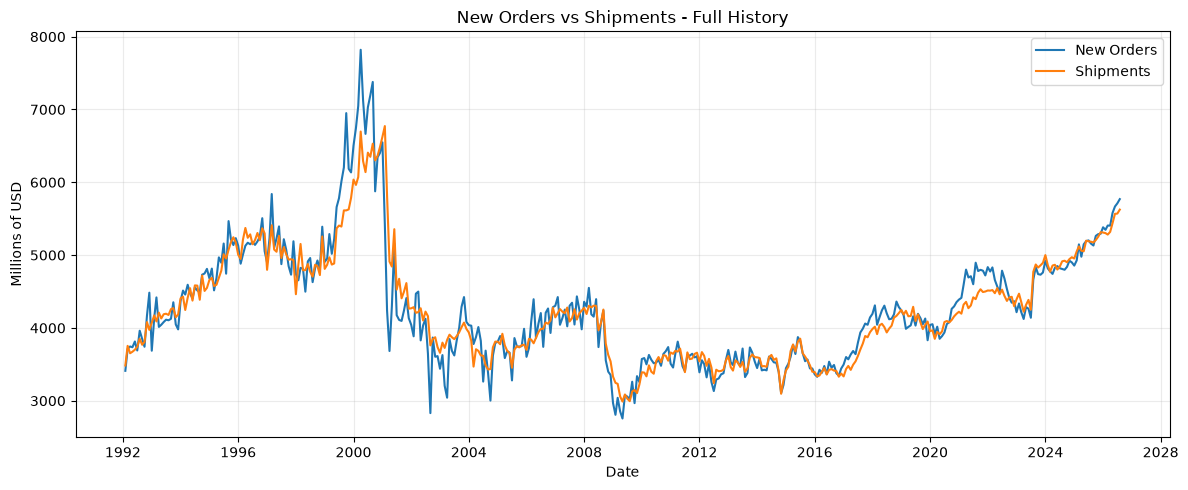

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\02_orders_vs_shipments_full_history.png


In [6]:
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    analysis_data["date"],
    analysis_data["new_orders"],
    label="New Orders",
)

ax.plot(
    analysis_data["date"],
    analysis_data["shipments"],
    label="Shipments",
)

ax.set_title("New Orders vs Shipments - Full History")
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "02_orders_vs_shipments_full_history.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

完整歷史圖顯示 New Orders 與 Shipments 長期大致一起移動，但不同時期會出現明顯差距。

可以看到：

- 1990 年代到 2000 年前後兩者都快速上升。
- 2000 年前後 New Orders 的波動明顯大於 Shipments。
- 2008–2009 左右兩者都有明顯下滑。
- 2016 之後又重新往上。
- 最近幾年兩條線再次往上，而且最新端 New Orders 位在 Shipments 上方。

**白話來說：**

Orders 和 Shipments 本來就不是永遠完全同步。產業景氣改變時，Orders 往往可以先和 Shipments 拉開。

所以「最新 Orders > Shipments」本身不是異常到前所未見；真正重要的是要看：

1. 這個差距有沒有持續。
2. Backlog 有沒有一起增加。

這也是為什麼不能只看一張長期圖就直接判斷交期風險。

**下一步：**把畫面縮到最近 5 年，看目前這波差距是怎麼形成的。


## Step 7｜放大最近 5 年的 Demand vs Shipment

### 這一格要做什麼？

完整歷史適合看大方向，但近期的月度差異太小，不容易看清。

因此只取最近 60 個月（5 年），再次畫 New Orders 與 Shipments。

同時加入 3-Month Moving Average，降低單月雜訊。


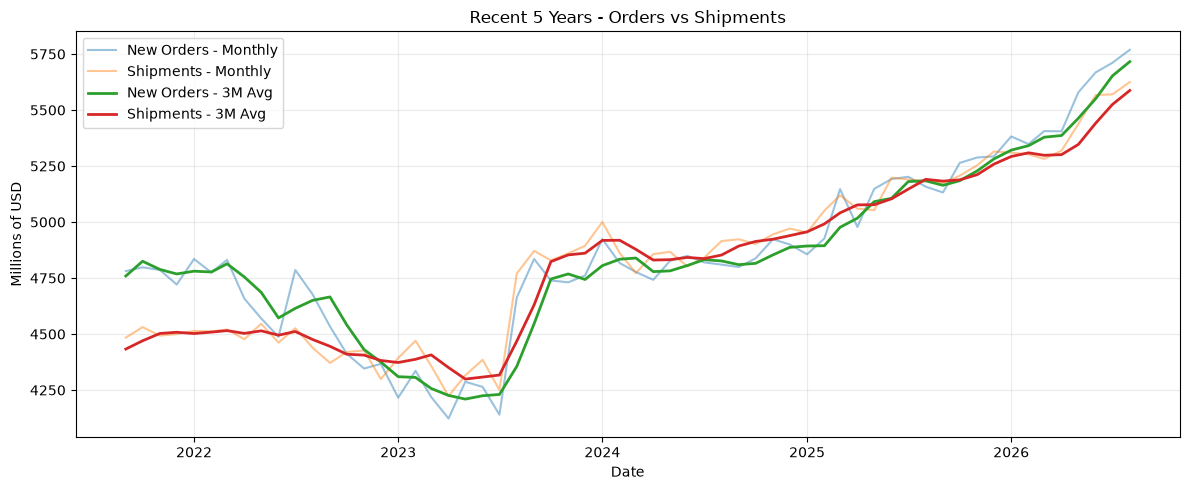

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\02_orders_vs_shipments_recent_5y.png


In [7]:
recent_5y = analysis_data.tail(60).copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    recent_5y["date"],
    recent_5y["new_orders"],
    alpha=0.45,
    label="New Orders - Monthly",
)

ax.plot(
    recent_5y["date"],
    recent_5y["shipments"],
    alpha=0.45,
    label="Shipments - Monthly",
)

ax.plot(
    recent_5y["date"],
    recent_5y["new_orders_3m_avg"],
    linewidth=2,
    label="New Orders - 3M Avg",
)

ax.plot(
    recent_5y["date"],
    recent_5y["shipments_3m_avg"],
    linewidth=2,
    label="Shipments - 3M Avg",
)

ax.set_title("Recent 5 Years - Orders vs Shipments")
ax.set_xlabel("Date")
ax.set_ylabel("Millions of USD")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "02_orders_vs_shipments_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


### 輸出解讀

最近 5 年的圖比完整歷史更清楚。

從圖上可以看到：

- 2022 前段 New Orders 一度明顯高於 Shipments。
- 2023 到 2024 一段時間，Shipments 多數時候反而高於 New Orders。
- 2025 之後兩者重新靠近。
- 進入 2026 後，New Orders 再次逐漸拉到 Shipments 上方。
- 最新 3 個月平均線也顯示 New Orders 位於 Shipments 上方。

**白話來說：**

現在的情況不是「五年來一直缺出貨」，而是經歷過不同階段：

**Orders 較強 → Shipments 較強 → 重新接近平衡 → 2026 Orders 再轉強。**

這個轉折比只說「現在 New Orders 很高」更重要，因為 Planner 真正要追蹤的是供需關係的方向變化。

**下一步：**直接計算 New Orders − Shipments，把每個月到底差多少量化出來。


## Step 8｜分析 Order Gap

### 這一格要做什麼？

`Order Gap = New Orders - Shipments`

把最近 5 年每個月的差額畫出來。

### 怎麼解讀？

- `> 0`：當月 Orders > Shipments。
- `< 0`：當月 Shipments > Orders。
- 接近 0：兩者大致平衡。

### 為什麼需要 Order Gap？

Book-to-Bill 是比例；Order Gap 則直接告訴「金額差多少」。

例如 Book-to-Bill 都是 1.05，在 1,000 百萬與 10,000 百萬的業務規模下，實際差額完全不同。


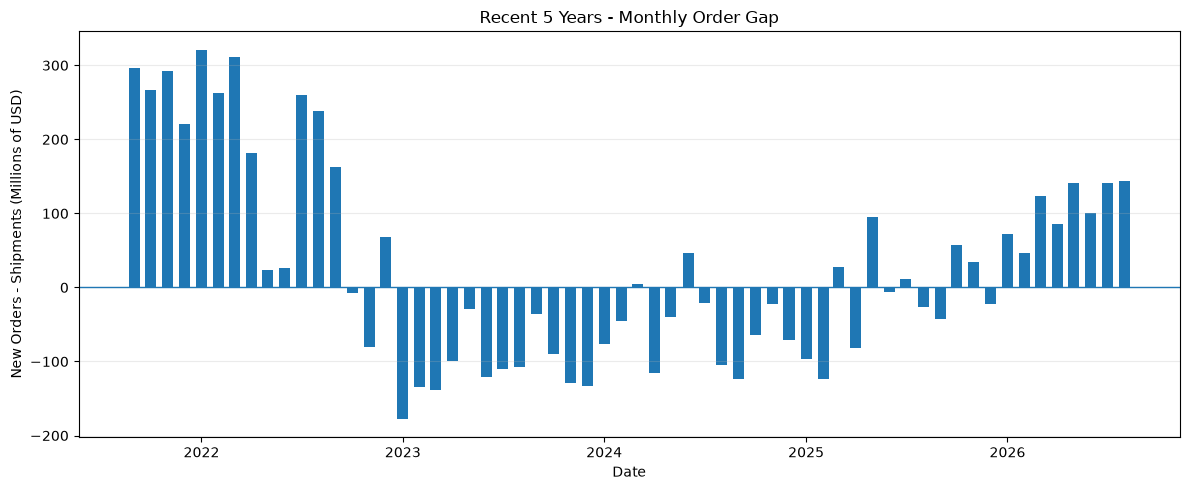

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\02_order_gap_recent_5y.png

In the latest 12 months: 10 months had Orders > Shipments, 2 months had Shipments > Orders.


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    recent_5y["date"],
    recent_5y["order_gap"],
    width=20,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title("Recent 5 Years - Monthly Order Gap")
ax.set_xlabel("Date")
ax.set_ylabel("New Orders - Shipments (Millions of USD)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "02_order_gap_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

positive_gap_months = int((recent_12m["order_gap"] > 0).sum())
negative_gap_months = int((recent_12m["order_gap"] < 0).sum())

print()
print(
    f"In the latest 12 months: "
    f"{positive_gap_months} months had Orders > Shipments, "
    f"{negative_gap_months} months had Shipments > Orders."
)


### 輸出解讀

最近 5 年的 Order Gap 圖顯示：

- 2021–2022 有一段很明顯的正 Gap。
- 2023–2024 有很多月份轉成負 Gap，代表當時 Shipments 高於 New Orders。
- 2025 的正負較混合。
- 2026 的柱子重新明顯轉正，而且近期正 Gap 有擴大的現象。

程式另外統計最近 12 個月：

```text
10 months had Orders > Shipments
2 months had Shipments > Orders
```

也就是最近 12 個月有 **10 / 12 個月（約 83%）** New Orders 高於 Shipments。

**白話來說：**

目前 Orders > Shipments 並不是偶發的一個月，而是在最近一年大部分月份都出現。

這比單純看到 2026-08 的 +144 更有意義，因為它顯示近期需求流入高於出貨的方向具有一定持續性。

⚠️ 但 `Order Gap` 不能直接當成 `Backlog 增量`。官方 Unfilled Orders 可能還會受到訂單取消、修正或其他統計調整影響。

**下一步：**用 Book-to-Bill 把這個差距換成「相對於出貨規模」的比例來看。


## Step 9｜分析 Book-to-Bill Ratio

### 公式

`Book-to-Bill = New Orders / Shipments`

### 白話

假設：

- New Orders = 105
- Shipments = 100

Book-to-Bill = `1.05`

代表當月每出貨 1 元的規模，同時約有 1.05 元的新訂單進來。

### 為什麼同時看單月與 3 個月？

單月可能受 timing 或資料 revision 影響，所以另外看 3 個月平均 Orders ÷ 3 個月平均 Shipments，判斷近期是否持續高於或低於 1。


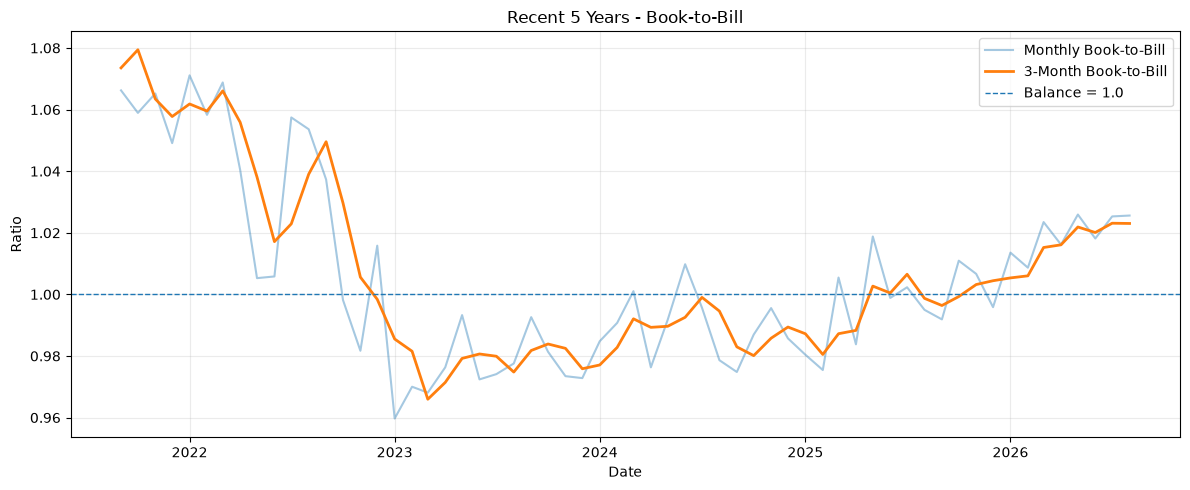

Saved: C:\Users\momo8\Desktop\electronic-components-planning\reports\figures\02_book_to_bill_recent_5y.png

Latest 3-Month Book-to-Bill: 1.023
Plain-language read: over the recent 3-month window, average incoming orders were higher than average shipments.


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    recent_5y["date"],
    recent_5y["book_to_bill"],
    alpha=0.40,
    label="Monthly Book-to-Bill",
)

ax.plot(
    recent_5y["date"],
    recent_5y["book_to_bill_3m"],
    linewidth=2,
    label="3-Month Book-to-Bill",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Balance = 1.0",
)

ax.set_title("Recent 5 Years - Book-to-Bill")
ax.set_xlabel("Date")
ax.set_ylabel("Ratio")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

figure_path = (
    REPORT_FIGURE_DIR
    / "02_book_to_bill_recent_5y.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)

latest_btb_3m = latest["book_to_bill_3m"]

print()
print(f"Latest 3-Month Book-to-Bill: {latest_btb_3m:.3f}")

if latest_btb_3m > 1:
    print(
        "Plain-language read: over the recent 3-month window, "
        "average incoming orders were higher than average shipments."
    )
elif latest_btb_3m < 1:
    print(
        "Plain-language read: over the recent 3-month window, "
        "average shipments were higher than average incoming orders."
    )
else:
    print(
        "Plain-language read: recent 3-month average orders and shipments were equal."
    )


### 輸出解讀

最新：

```text
3-Month Book-to-Bill = 1.023
```

代表最近三個月平均來看：

> 每 1.000 的 Shipment 規模，大約對應 1.023 的 New Orders 流入。

也就是最近三個月 New Orders 約比 Shipments 高 **2.3% 左右**。

圖上可以看到：

- 2021–2022 的 3M Book-to-Bill 明顯高於 1。
- 2023–2024 多數時間低於 1。
- 2025 逐漸回到 1 附近。
- 2026 則重新站到 1 以上，最新約 **1.023**。

**白話來說：**

目前不只是單月 Orders 高於 Shipments，最近三個月平均也是如此，因此「近期需求流入稍快於出貨」這個判讀有更多支持。

但 1.023 並不是非常誇張的失衡，它代表的是**輕度、但持續的需求壓力訊號**。

⚠️ 不能把 1.023 解讀成：
- 延誤機率 2.3%
- 產能不足 2.3%
- Backlog 一定增加 2.3%

它只是一個 Orders / Shipments 的金額比率。

**下一步：**把視窗拉長到 12 個月，確認這不是只有最近幾個月才出現的短期波動。


## Step 10｜比較最近 12 個月累計 Orders 與 Shipments

### 這一格要做什麼？

單月和 3 個月都偏短。

所以再看 Rolling 12 Months：

- 最近 12 個月 New Orders 合計
- 最近 12 個月 Shipments 合計
- 12-Month Book-to-Bill

### 為什麼有用？

如果 12 個月累計 Orders 仍高於 Shipments，代表需求流入高於出貨不是只發生在一兩個月，而是較長時間的現象。


In [10]:
analysis_data["orders_12m_sum"] = (
    analysis_data["new_orders"]
    .rolling(window=12)
    .sum()
)

analysis_data["shipments_12m_sum"] = (
    analysis_data["shipments"]
    .rolling(window=12)
    .sum()
)

analysis_data["book_to_bill_12m"] = (
    analysis_data["orders_12m_sum"]
    / analysis_data["shipments_12m_sum"]
)

latest = analysis_data.iloc[-1]

print("ROLLING 12-MONTH SUMMARY")
print("-" * 60)
print(
    f"New Orders: {latest['orders_12m_sum']:,.0f} million USD"
)
print(
    f"Shipments: {latest['shipments_12m_sum']:,.0f} million USD"
)
print(
    f"12-Month Book-to-Bill: {latest['book_to_bill_12m']:.3f}"
)

if latest["book_to_bill_12m"] > 1:
    print(
        "Plain-language read: cumulative incoming orders exceeded cumulative shipments over the latest 12 months."
    )
elif latest["book_to_bill_12m"] < 1:
    print(
        "Plain-language read: cumulative shipments exceeded cumulative incoming orders over the latest 12 months."
    )
else:
    print(
        "Plain-language read: cumulative orders and shipments were equal over the latest 12 months."
    )


ROLLING 12-MONTH SUMMARY
------------------------------------------------------------
New Orders: 65,245 million USD
Shipments: 64,362 million USD
12-Month Book-to-Bill: 1.014
Plain-language read: cumulative incoming orders exceeded cumulative shipments over the latest 12 months.


### 輸出解讀

最近 12 個月累計：

```text
New Orders = 65,245 million USD
Shipments  = 64,362 million USD
12-Month Book-to-Bill = 1.014
```

兩者相差：

**65,245 − 64,362 = 883 百萬美元**

也就是最近 12 個月累積 New Orders 約比累積 Shipments 高 **1.4% 左右**。

**白話來說：**

前面 3M Book-to-Bill = **1.023**，現在 12M 也仍然大於 1（**1.014**）。

因此這個訊號不只是最近一兩個月才出現；用最近一年累計來看，Orders 仍稍微高於 Shipments。

同時，3M 的 1.023 高於 12M 的 1.014，代表**近期的 Orders / Shipments 壓力比整個過去一年更強一些**。

這是一個值得繼續往 Backlog 查的結果。

⚠️ 仍然不能把 883 百萬美元直接稱為「新增 Backlog 883」，因為 Order flow 與官方 Unfilled Orders 存量不是完全相同的概念。

**下一步：**查看完整年度資料，確認近年的關係是怎麼從低於 1 轉到現在高於 1。


## Step 11｜建立年度 Demand vs Shipment Summary

### 這一格要做什麼？

把月資料彙整成年資料，產生：

- Annual New Orders
- Annual Shipments
- Annual Order Gap
- Annual Book-to-Bill

### 為什麼還需要年表？

月圖適合看 timing；年表適合在簡報或面試中快速說明產業在不同年份的需求／出貨平衡。

這裡只保留「完整 12 個月份」的年份，避免把尚未結束的年度和完整年度直接比較。


In [11]:
yearly_summary = (
    analysis_data
    .assign(year=analysis_data["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        month_count=("date", "count"),
        annual_new_orders=("new_orders", "sum"),
        annual_shipments=("shipments", "sum"),
    )
)

yearly_summary = yearly_summary.loc[
    yearly_summary["month_count"].eq(12)
].copy()

yearly_summary["annual_order_gap"] = (
    yearly_summary["annual_new_orders"]
    - yearly_summary["annual_shipments"]
)

yearly_summary["annual_book_to_bill"] = (
    yearly_summary["annual_new_orders"]
    / yearly_summary["annual_shipments"]
)

yearly_summary["annual_book_to_bill"] = (
    yearly_summary["annual_book_to_bill"]
    .round(3)
)

display(yearly_summary.tail(10))


,year,month_count,annual_new_orders,annual_shipments,annual_order_gap,annual_book_to_bill
24,2016,12,40985,40670,315,1.008
25,2017,12,45597,43513,2084,1.048
26,2018,12,50523,48489,2034,1.042
27,2019,12,48982,49754,-772,0.984
28,2020,12,48743,48298,445,1.009
29,2021,12,56180,52499,3681,1.070
30,2022,12,55279,53513,1766,1.033
31,2023,12,53314,54619,-1305,0.976
32,2024,12,58026,58657,-631,0.989
33,2025,12,61585,61757,-172,0.997


### 輸出解讀

最近 10 個完整年度的結果很有助於理解目前的轉折：

| 年份 | Annual Book-to-Bill | 年度 Order Gap（百萬美元） |
|---|---:|---:|
| 2016 | 1.008 | +315 |
| 2017 | 1.048 | +2,084 |
| 2018 | 1.042 | +2,034 |
| 2019 | 0.984 | -772 |
| 2020 | 1.009 | +445 |
| 2021 | 1.070 | +3,681 |
| 2022 | 1.033 | +1,766 |
| 2023 | 0.976 | -1,305 |
| 2024 | 0.989 | -631 |
| 2025 | 0.997 | -172 |

最值得注意的是：

- 2021、2022 Orders 明顯高於 Shipments。
- 2023、2024 轉成 Shipments 高於 Orders。
- 2025 已經非常接近平衡（0.997）。
- 2026 尚未滿 12 個月，所以這張完整年度表刻意不把 2026 放進去。

**白話來說：**

近幾年可以看到一個很清楚的變化：

**2021–2022 demand inflow 強 → 2023–2024 shipment 相對強 → 2025 接近平衡 → 2026 YTD 再度出現 Orders 高於 Shipments。**

這讓目前 2026 的 3M / 12M Book-to-Bill > 1 更值得關注，因為它可能代表近期方向又發生轉變。

⚠️ 這仍然是產業層級資料，不是 ASE 自己的接單紀錄。

**下一步：**把這本 Notebook 最重要的指標收斂成一張 Planner Summary。


## Step 12｜建立本 Notebook 的 Planner Summary

### 這一格要做什麼？

把 02 最重要的結果收斂成一張 summary table：

- 最新月份
- New Orders
- Shipments
- Order Gap
- Monthly Book-to-Bill
- 3M Book-to-Bill
- 12M Book-to-Bill
- Orders YoY
- Shipments YoY
- 最近 12 個月中 Orders > Shipments 的月份數

### 為什麼需要這張表？

真正工作或面試時，不可能把整本 Notebook 從頭翻到尾才回答「現在 demand pressure 怎麼樣」。

Summary 是把分析轉成可溝通的 Planner 資訊。


In [12]:
latest = analysis_data.iloc[-1]

months_orders_above_shipments_12m = int(
    (analysis_data.tail(12)["order_gap"] > 0).sum()
)

planner_summary = pd.DataFrame(
    {
        "metric": [
            "Latest month",
            "New Orders (USD mn)",
            "Shipments (USD mn)",
            "Order Gap (USD mn)",
            "Monthly Book-to-Bill",
            "3M Book-to-Bill",
            "12M Book-to-Bill",
            "New Orders YoY",
            "Shipments YoY",
            "Orders > Shipments months (last 12M)",
        ],
        "value": [
            latest["date"].strftime("%Y-%m"),
            round(float(latest["new_orders"]), 2),
            round(float(latest["shipments"]), 2),
            round(float(latest["order_gap"]), 2),
            round(float(latest["book_to_bill"]), 3),
            round(float(latest["book_to_bill_3m"]), 3),
            round(float(latest["book_to_bill_12m"]), 3),
            f"{latest['new_orders_yoy_pct']:.2f}%",
            f"{latest['shipments_yoy_pct']:.2f}%",
            months_orders_above_shipments_12m,
        ],
    }
)

display(planner_summary)

print()
print("PLANNER INTERPRETATION")
print("-" * 60)

if latest["book_to_bill_3m"] > 1:
    print(
        "1. Recent 3-month demand inflow is running above shipment output."
    )
else:
    print(
        "1. Recent 3-month shipment output is running at or above demand inflow."
    )

if latest["book_to_bill_12m"] > 1:
    print(
        "2. The same imbalance is also visible over the latest 12-month window."
    )
else:
    print(
        "2. The latest 12-month window does not show cumulative orders above shipments."
    )

print(
    "3. This is not yet a delivery-delay conclusion. "
    "The next notebook must check actual Unfilled Orders (backlog)."
)


,metric,value
0,Latest month,2026-08
1,New Orders (USD mn),5769.0
2,Shipments (USD mn),5625.0
3,Order Gap (USD mn),144.0
4,Monthly Book-to-Bill,1.026
5,3M Book-to-Bill,1.023
6,12M Book-to-Bill,1.014
7,New Orders YoY,11.85%
8,Shipments YoY,8.51%
9,Orders > Shipments months (last 12M),10



PLANNER INTERPRETATION
------------------------------------------------------------
1. Recent 3-month demand inflow is running above shipment output.
2. The same imbalance is also visible over the latest 12-month window.
3. This is not yet a delivery-delay conclusion. The next notebook must check actual Unfilled Orders (backlog).


### 輸出解讀

這本 Notebook 最重要的實際結果可以整理成：

| 指標 | 最新結果 |
|---|---:|
| Latest month | 2026-08 |
| New Orders | 5,769 百萬美元 |
| Shipments | 5,625 百萬美元 |
| Order Gap | +144 百萬美元 |
| Monthly Book-to-Bill | 1.026 |
| 3M Book-to-Bill | 1.023 |
| 12M Book-to-Bill | 1.014 |
| New Orders YoY | +11.85% |
| Shipments YoY | +8.51% |
| 最近 12M Orders > Shipments | 10 / 12 個月 |

### 最終白話結論

目前資料支持三件事：

**1. 最新月份 New Orders 高於 Shipments。**  
2026-08 Orders 比 Shipments 多 **144 百萬美元**。

**2. 不是只有單月。**  
最近 3 個月 Book-to-Bill = **1.023**，最近 12 個月 = **1.014**，而且最近 12 個月有 **10 個月** Orders > Shipments。

**3. New Orders 目前成長得比 Shipments 快。**  
2026-08 New Orders YoY = **+11.85%**，Shipments YoY = **+8.51%**。

因此目前最合理的 Planner 判讀是：

> **近期 incoming order demand 稍微跑在 shipment output 前面，而且這個方向具有持續性，因此下一步應檢查官方 Unfilled Orders 是否也同步累積。**

### 這裡還不能說什麼？

目前仍不能直接說：

- 產能不足。
- 客戶交期會延誤。
- Backlog 一定惡化。
- ASE 應增加多少產能。

因為這些結論需要真正的 Backlog、Capacity、Product Mix、WIP 與 Customer Priority。

**下一步：`03_backlog_analysis.ipynb`**

要正式回答：

**Demand pressure 是否真的轉成 Backlog / 履約壓力？**


## Step 13｜保存 02 的分析結果

### 這一格要做什麼？

將這本 Notebook 建立的 KPI 與 summary 保存起來，讓後面的 Backlog、Forecast 與 Dashboard 可以直接重用。

輸出：

- `demand_shipment_monthly_metrics.csv`
- `demand_shipment_yearly_summary.csv`
- `demand_shipment_planner_summary.csv`

### 為什麼要保存？

下一本不需要重算同一批 KPI；而且每一本 Notebook 都留下清楚的 input → analysis → output，GitHub 的專案流程會比較完整。


In [13]:
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

monthly_output_path = (
    REPORT_TABLE_DIR
    / "demand_shipment_monthly_metrics.csv"
)

yearly_output_path = (
    REPORT_TABLE_DIR
    / "demand_shipment_yearly_summary.csv"
)

summary_output_path = (
    REPORT_TABLE_DIR
    / "demand_shipment_planner_summary.csv"
)

analysis_data.to_csv(
    monthly_output_path,
    index=False,
)

yearly_summary.to_csv(
    yearly_output_path,
    index=False,
)

planner_summary.to_csv(
    summary_output_path,
    index=False,
)

print("Saved:", monthly_output_path.name)
print("Saved:", yearly_output_path.name)
print("Saved:", summary_output_path.name)


Saved: demand_shipment_monthly_metrics.csv
Saved: demand_shipment_yearly_summary.csv
Saved: demand_shipment_planner_summary.csv


### 輸出解讀

三份分析結果都成功保存：

```text
demand_shipment_monthly_metrics.csv
demand_shipment_yearly_summary.csv
demand_shipment_planner_summary.csv
```

代表 02 的分析成果已經固定下來，後面的 Notebook 不需要重算同一批 KPI。

## 02 最終完成的分析鏈

這一本不是單純畫圖，而是依序完成：

**官方月資料**
→ **New Orders**
→ **Shipments**
→ **Order Gap**
→ **Book-to-Bill**
→ **MoM / YoY**
→ **3M 短期壓力**
→ **12M 累積壓力**
→ **年度趨勢**
→ **Planner Summary**

### 目前最重要的發現

截至 2026-08：

- New Orders = **5,769 百萬美元**
- Shipments = **5,625 百萬美元**
- Monthly Book-to-Bill = **1.026**
- 3M Book-to-Bill = **1.023**
- 12M Book-to-Bill = **1.014**
- 最近 12 個月有 **10 / 12 個月** Orders > Shipments

所以 02 已經找到一個值得追查的訊號：

> **近期 Orders 流入速度持續略高於 Shipments。**

但刻意沒有把它直接稱為 delivery risk。

下一本 `03_backlog_analysis.ipynb` 會直接使用官方 `Unfilled Orders`，確認這個 demand pressure 是否真的變成：

**Backlog Growth → Backlog Coverage → Fulfillment Pressure**
